# TOX3GNN – Optuna + 30-Run Publishable Experiment
 **T4 GPU**


## 1 · Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Edit this to match where your TOX folder lives in Drive ──────
DRIVE_ROOT = '/content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX'

os.makedirs(f'{DRIVE_ROOT}/checkpoints_tox21', exist_ok=True)
os.makedirs(f'{DRIVE_ROOT}/results_tox21',     exist_ok=True)

print('Drive mounted. Root:', DRIVE_ROOT)
print('Contents:', os.listdir(DRIVE_ROOT))

Mounted at /content/drive
Drive mounted. Root: /content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX
Contents: ['tox21_dataset (1).csv', 'tox21_dataset.csv', 'TOX3GNN.py', 'optim_TOX3GNN.py', 'results_tox21', 'checkpoints_tox21', 'feat_corr.py', 'utils.py', '__pycache__']


## 2 · Install dependencies

In [ ]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'rdkit', 'optuna'],  check=True)

import torch
print(f'torch={torch.__version__}  cuda={torch.cuda.is_available()}')
print('Dependencies ready.')


torch=2.11.0+cu128  cuda=True
Dependencies ready.


## 3 · Imports

In [ ]:
import os, sys, time, random, shutil, warnings, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import optuna

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 4 · Load `utils.py` from Drive
This imports your **exact** implementations — nothing is rewritten here.

In [ ]:
# utils.py must be in DRIVE_ROOT alongside tox21_dataset.csv
sys.path.insert(0, DRIVE_ROOT)

from utils import (
    one_hot_encoding,
    get_atom_features,
    get_bond_features,
    create_pytorch_geometric_graph_data_list_from_smiles_and_labels,
    scaffold_split,
    save_ckp,
    load_ckp,
    optimizer_to,
    round_to_4,
)

# Alias used throughout this notebook
smiles_to_graph_list = create_pytorch_geometric_graph_data_list_from_smiles_and_labels

print('utils.py loaded from Drive — using your exact implementations.')


utils.py loaded from Drive — using your exact implementations.


## 5 · Configuration

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_CSV       = f'{DRIVE_ROOT}/tox21_dataset.csv'
CHECKPOINT_DIR = f'{DRIVE_ROOT}/checkpoints_tox21'
RESULTS_DIR    = f'{DRIVE_ROOT}/results_tox21'

# ── Optuna toggle ─────────────────────────────────────────────────────────────
# Set RUN_OPTUNA = True to search for hyperparameters first.
# Set False to skip Optuna and use the known-best params below directly.
RUN_OPTUNA   = False
N_TRIALS     = 20      # number of Optuna trials (each trains 50 epochs)

# ── Known-best params (used when RUN_OPTUNA = False, or as Optuna fallback) ──
KNOWN_LAYER_TYPES = ['sage', 'gin', 'sage']
KNOWN_HIDDEN = 224
KNOWN_DROPOUT = 0.0006
KNOWN_LR = 0.0004

# ── 30-run experiment settings ────────────────────────────────────────────────
N_RUNS = 30
MAX_EPOCHS = 200
EVAL_EVERY = 10
PATIENCE = 30
NUM_GRAPHS_PER_BATCH = 64
USE_SCAFFOLD_SPLIT = True
GLOBAL_SEED = 42
POS_WEIGHT = 6.0      # BCEWithLogitsLoss weight for positive class

print('Config OK')
print(f'  RUN_OPTUNA={RUN_OPTUNA}  N_TRIALS={N_TRIALS}')
print(f'  scaffold_split={USE_SCAFFOLD_SPLIT}  N_RUNS={N_RUNS}  MAX_EPOCHS={MAX_EPOCHS}')


Config OK
  RUN_OPTUNA=False  N_TRIALS=20
  scaffold_split=True  N_RUNS=30  MAX_EPOCHS=200


## 6 · Load dataset & build splits

In [ ]:
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

df = pd.read_csv(DATA_CSV)
df_task = df[['smiles', 'SR-ARE']].dropna().reset_index(drop=True)
print(f'Compounds after dropna: {len(df_task)}')
print(df_task['SR-ARE'].value_counts())

X_smiles_raw = list(df_task['smiles'])
y_labels_raw = list(df_task['SR-ARE'])


from rdkit import Chem
X_smiles, y_labels = [], []
for smi, y_val in zip(X_smiles_raw, y_labels_raw):
    if Chem.MolFromSmiles(smi) is not None:
        X_smiles.append(smi)
        y_labels.append(y_val)

print(f'Valid SMILES: {len(X_smiles)} / {len(X_smiles_raw)}')

print('Building molecular graphs (1-2 min)...')
data_list = smiles_to_graph_list(X_smiles, y_labels)
assert len(data_list) == len(X_smiles), "Length mismatch after graph building!"
print(f'Graph list: {len(data_list)} molecules')

# ── Fixed split — same across all 30 runs ────────────────────────────────────
if USE_SCAFFOLD_SPLIT:
    train_idx, val_idx, test_idx = scaffold_split(X_smiles, seed=GLOBAL_SEED)
else:
    all_idx = list(range(len(data_list)))
    train_idx, temp = train_test_split(all_idx, test_size=0.4, random_state=GLOBAL_SEED)
    val_idx, test_idx = train_test_split(temp,   test_size=0.5, random_state=GLOBAL_SEED)
    print(f'Random split → train:{len(train_idx)} val:{len(val_idx)} test:{len(test_idx)}')

val_loader  = DataLoader([data_list[i] for i in val_idx],
                         batch_size=NUM_GRAPHS_PER_BATCH, shuffle=False, drop_last=False)
test_loader = DataLoader([data_list[i] for i in test_idx],
                         batch_size=NUM_GRAPHS_PER_BATCH, shuffle=False, drop_last=False)
trainval_data = [data_list[i] for i in list(train_idx) + list(val_idx)]

print('Data splits ready.')


Compounds after dropna: 5832
SR-ARE
0.0    4890
1.0     942
Name: count, dtype: int64


[14:22:24] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:22:25] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:22:25] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:22:25] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:22:25] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:22:25] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:22:25] Explicit valence for atom # 16 Al, 6, is greater than permitted


Valid SMILES: 5825 / 5832
Building molecular graphs (1-2 min)...
Graph list: 5825 molecules
Scaffold split → train: 3497, val: 1285, test: 1043
Data splits ready.


## 7 · GNN model

In [ ]:
class GNN(torch.nn.Module):
    def __init__(self, layer_types, hidden_dim, dropout):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        in_dim = 79  # fixed by get_atom_features in utils.py
        for lt in layer_types:
            if lt == 'gcn':
                self.convs.append(GCNConv(in_dim, hidden_dim))
            elif lt == 'gat':
                self.convs.append(GATConv(in_dim, hidden_dim))
            elif lt == 'gin':
                mlp = nn.Sequential(
                    nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
                self.convs.append(GINConv(mlp, eps=0.00005, train_eps=True))
            elif lt == 'sage':
                self.convs.append(SAGEConv(in_dim, hidden_dim))
            else:
                raise ValueError(f'Unknown layer type: {lt}')
            in_dim = hidden_dim
        self.drop = nn.Dropout(p=dropout)
        self.out  = Linear(hidden_dim * 2, 1)

    def forward(self, x, edge_index, batch_index):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = torch.tanh(x)
        x = self.drop(x)
        x = torch.cat([gmp(x, batch_index), gap(x, batch_index)], dim=1)
        return self.out(x)


def evaluate_auc(model, loader, device):
    """ROC-AUC with raw sigmoid probabilities — correct for AUC (no thresholding)."""
    model.eval()
    y_true_all, y_score_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x.float(), batch.edge_index, batch.batch).squeeze()
            probs  = torch.sigmoid(logits)
            y_true_all.append(batch.y.cpu().numpy())
            y_score_all.append(probs.cpu().numpy())
    return roc_auc_score(np.concatenate(y_true_all), np.concatenate(y_score_all))


print('GNN defined.')


GNN defined.


## 8 · Optuna hyperparameter search

In [ ]:
pos_weight_tensor = torch.FloatTensor([POS_WEIGHT]).to(device)

if RUN_OPTUNA:
    # Build a fixed train loader for Optuna trials
    optuna_train_loader = DataLoader(
        [data_list[i] for i in train_idx],
        batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True, drop_last=True)

    def objective(trial):
        layer_types = [trial.suggest_categorical(f'layer_{i}', ['gcn','gat','gin','sage'])
                       for i in range(3)]
        hidden_dim  = trial.suggest_int('hidden_dim', 64, 256, step=32)
        dropout     = trial.suggest_float('dropout', 0.0, 0.5)
        lr          = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

        m   = GNN(layer_types, hidden_dim, dropout).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=lr)
        crit = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

        best_val, patience_ctr = 0.0, 0
        for epoch in range(100):
            m.train()
            for batch in optuna_train_loader:
                batch = batch.to(device)
                opt.zero_grad()
                pred = m(batch.x.float(), batch.edge_index, batch.batch).squeeze()
                crit(pred, batch.y).backward()
                opt.step()

            val_auc = evaluate_auc(m, val_loader, device)
            trial.report(val_auc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            if val_auc > best_val:
                best_val, patience_ctr = val_auc, 0
            else:
                patience_ctr += 1
                if patience_ctr >= 5:
                    break
        return best_val

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    study  = optuna.create_study(direction='maximize', pruner=pruner)

    print(f'Running Optuna ({N_TRIALS} trials)...')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_p      = study.best_trial.params
    best_layer_types = [best_p[f'layer_{i}'] for i in range(3)]
    best_hidden      = best_p['hidden_dim']
    best_dropout     = round_to_4(best_p['dropout'])
    best_lr          = round_to_4(best_p['lr'])

    print(f'\nBest trial AUC: {study.best_trial.value:.4f}')
    print(f'  layers={best_layer_types}  hidden={best_hidden}  dropout={best_dropout}  lr={best_lr}')

    # Save Optuna results to Drive
    from datetime import datetime
    today = datetime.today().strftime('%Y-%m-%d')
    optune_filename ="_".join(['optuna_results',today])
    optuna_path = os.path.join(RESULTS_DIR, optune_filename)
    with open(optuna_path, 'w') as f:
        f.write('Optuna Study Results\n' + '='*60 + '\n')
        f.write(f'Best AUC: {study.best_trial.value:.6f}\n')
        f.write(f'Best params:\n')
        for k, v in study.best_trial.params.items():
            f.write(f'  {k}: {round_to_4(v)}\n')
        f.write('\nAll trials (sorted):\n' + '='*60 + '\n')
        for rank, t in enumerate(sorted(
            [t for t in study.trials if t.value is not None],
            key=lambda t: t.value, reverse=True), 1):
            f.write(f'{rank}. Trial #{t.number}: AUC={t.value:.6f} | {t.params}\n')
    print(f'Optuna results saved to {optuna_path}')

else:
    best_layer_types = KNOWN_LAYER_TYPES
    best_hidden      = KNOWN_HIDDEN
    best_dropout     = KNOWN_DROPOUT
    best_lr          = KNOWN_LR
    print(f'Skipping Optuna — using known-best params:')
    print(f'  layers={best_layer_types}  hidden={best_hidden}  dropout={best_dropout}  lr={best_lr}')


Skipping Optuna — using known-best params:
  layers=['sage', 'gin', 'sage']  hidden=224  dropout=0.0006  lr=0.0004


## 9 · Save helpers
Uses `save_ckp` from your `utils.py`.

In [ ]:
def save_run_checkpoint(state, is_best, ckpt_dir, model_dir, run_id, name):
    """Thin wrapper around utils.save_ckp that builds the expected paths."""
    os.makedirs(ckpt_dir,  exist_ok=True)
    os.makedirs(model_dir, exist_ok=True)
    ckpt_filename  = f'/checkpoints_{name}_run{run_id:02d}_tox21.pt'
    model_filename = f'/model_{name}_run{run_id:02d}_tox21.pt'
    save_ckp(state, is_best, ckpt_dir, model_dir, ckpt_filename, model_filename)


def append_run_result(results_dir, name, run_id, best_auc, auc_history):
    """Write per-run AUC to the model txt log and master CSV."""
    # per-model txt (matches original paper style)
    txt_path = os.path.join(results_dir, f'{name}.txt')
    with open(txt_path, 'a') as f:
        f.write(f'run:{run_id:02d}  best_auc:{best_auc:.6f}\n')

    # master CSV — one row per run, columns for each eval checkpoint AUC
    csv_path     = os.path.join(results_dir, 'all_runs_summary.csv')
    write_header = not os.path.exists(csv_path)
    with open(csv_path, 'a', newline='') as f:
        w = csv.writer(f)
        if write_header:
            ep_cols = [f'auc_ep{(i+1)*EVAL_EVERY}' for i in range(len(auc_history))]
            w.writerow(['model', 'run', 'best_auc'] + ep_cols)
        w.writerow([name, run_id, best_auc] + auc_history)


print('Save helpers ready.')


Save helpers ready.


## 10 · 30-Run experiment
Each run: fresh weights, same split. ~5–10 min/run on T4.

In [ ]:
NAME      = '_'.join(best_layer_types)
ckpt_dir  = os.path.join(CHECKPOINT_DIR, NAME)
model_dir = os.path.join(CHECKPOINT_DIR, NAME + '_best')

print(f'Model name : {NAME}')
print(f'Checkpoints: {ckpt_dir}')
print(f'Results    : {RESULTS_DIR}')
print()

all_run_aucs     = []
experiment_start = time.time()
for run in range(N_RUNS):
    run_seed = run   # seeds 0 … 29
    torch.manual_seed(run_seed)
    np.random.seed(run_seed)
    random.seed(run_seed)

    # Fresh model + optimiser every run
    model     = GNN(best_layer_types, best_hidden, best_dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    # Shuffle trainval differently each run
    train_loader = DataLoader(
        trainval_data,
        batch_size=NUM_GRAPHS_PER_BATCH,
        shuffle=True, drop_last=True,
        generator=torch.Generator().manual_seed(run_seed),
    )

    best_auc     = 0.0
    patience_ctr = 0
    auc_history  = []
    run_start    = time.time()

    for epoch in range(MAX_EPOCHS):
        # train
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch.x.float(), batch.edge_index, batch.batch).squeeze()
            criterion(pred, batch.y).backward()
            optimizer.step()

        # evaluate
        if (epoch + 1) % EVAL_EVERY == 0:
            test_auc = evaluate_auc(model, test_loader, device)
            auc_history.append(round(test_auc, 6))

            is_best = test_auc > best_auc
            if is_best:
                best_auc     = test_auc
                patience_ctr = 0
                state = {
                    'epoch':      epoch + 1,
                    'state_dict': model.state_dict(),
                    'optimizer':  optimizer.state_dict(),
                    'auc':        best_auc,
                    'layers':     best_layer_types,
                    'hidden':     best_hidden,
                    'dropout':    best_dropout,
                    'lr':         best_lr,
                }
                save_run_checkpoint(state, True, ckpt_dir, model_dir, run, NAME)
            else:
                patience_ctr += 1

            if patience_ctr >= PATIENCE:
                print(f'  Run {run:02d} | Early stop @ epoch {epoch+1} | best AUC {best_auc:.4f}')
                break

    all_run_aucs.append(best_auc)
    append_run_result(RESULTS_DIR, NAME, run, best_auc, auc_history)

    run_mins   = (time.time() - run_start) / 60
    total_mins = (time.time() - experiment_start) / 60
    print(f'Run {run:02d}/29 | best AUC {best_auc:.4f} | {run_mins:.1f}m/run | total {total_mins:.1f}m')

print(f'\n{"="*50}')
print(f'EXPERIMENT COMPLETE — {NAME}')
print(f'  Mean AUC : {np.mean(all_run_aucs):.4f}')
print(f'  Std  AUC : {np.std(all_run_aucs):.4f}')
print(f'  Min  AUC : {np.min(all_run_aucs):.4f}')
print(f'  Max  AUC : {np.max(all_run_aucs):.4f}')
print(f'  Results  : {RESULTS_DIR}')


Model name : sage_gin_sage
Checkpoints: /content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX/checkpoints_tox21/sage_gin_sage
Results    : /content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX/results_tox21

Run 00/29 | best AUC 0.8015 | 2.4m/run | total 2.4m
Run 01/29 | best AUC 0.7909 | 2.3m/run | total 4.7m
Run 02/29 | best AUC 0.8001 | 2.3m/run | total 7.0m
Run 03/29 | best AUC 0.7933 | 2.3m/run | total 9.4m
Run 04/29 | best AUC 0.7926 | 2.3m/run | total 11.7m
Run 05/29 | best AUC 0.7935 | 2.4m/run | total 14.0m
Run 06/29 | best AUC 0.7870 | 2.3m/run | total 16.4m
Run 07/29 | best AUC 0.7911 | 2.3m/run | total 18.7m
Run 08/29 | best AUC 0.7925 | 2.3m/run | total 21.0m
Run 09/29 | best AUC 0.7970 | 2.3m/run | total 23.3m
Run 10/29 | best AUC 0.7944 | 2.3m/run | total 25.6m
Run 11/29 | best AUC 0.7877 | 2.3m/run | total 27.9m
Run 12/29 | best AUC 0.7977 | 2.3m/run | total 30.1m
Run 13/29 | best AUC 0.7937 | 2.3m/run | total 32.4m
Run 14/29 | best AUC 0.7937 | 2.3m/run | total 34.7m
Run

## 11 · Statistical significance
Run after you have 30-run results for all 4 baselines. Paste the AUC lists below.

In [ ]:
# Fill these in after running each baseline (GCN/GAT/GIN/SAGE) for 30 runs
baseline_aucs = {
    'GCN' : [],   # list of 30 best-AUC values
    'GAT' : [],
    'GIN' : [],
    'SAGE': [],
}

print(f'Hybrid ({NAME}): mean={np.mean(all_run_aucs):.4f} ± {np.std(all_run_aucs):.4f}')
print()
header = f'{"Model":<8}  {"Mean":>7}  {"Std":>7}  {"p-value":>12}  {"Significant?":>13}'
print(header)
print('-' * len(header))
for bname, baucs in baseline_aucs.items():
    if len(baucs) != 30:
        print(f'{bname:<8}  (need 30 values)')
        continue
    _, p = stats.mannwhitneyu(all_run_aucs, baucs, alternative='greater')
    sig  = 'YES p<0.05' if p < 0.05 else 'no'
    print(f'{bname:<8}  {np.mean(baucs):>7.4f}  {np.std(baucs):>7.4f}  {p:>12.2e}  {sig:>13}')


Hybrid (gcn_gin_gin): mean=0.7839 ± 0.0092

Model        Mean      Std       p-value   Significant?
-------------------------------------------------------
GCN       (need 30 values)
GAT       (need 30 values)
GIN       (need 30 values)
SAGE      (need 30 values)


## 12 · Results plots

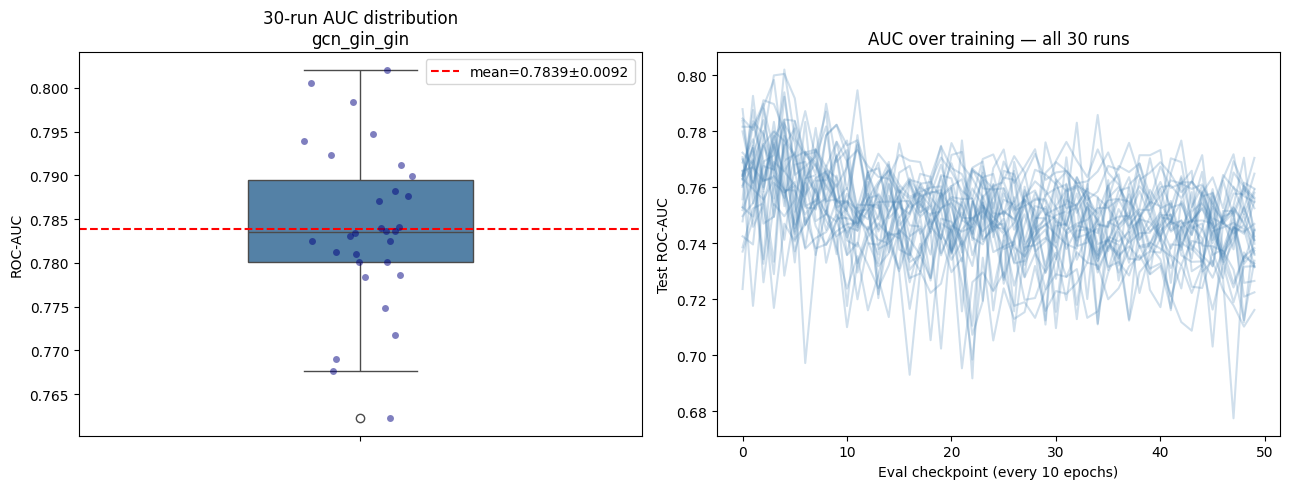

Saved to /content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX/results_tox21/gcn_gin_gin_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: boxplot + strip
sns.boxplot( y=all_run_aucs, ax=axes[0], color='steelblue', width=0.4)
sns.stripplot(y=all_run_aucs, ax=axes[0], color='navy', alpha=0.5, jitter=True)
axes[0].axhline(np.mean(all_run_aucs), color='red', ls='--',
                label=f'mean={np.mean(all_run_aucs):.4f}±{np.std(all_run_aucs):.4f}')
axes[0].set_title(f'30-run AUC distribution\n{NAME}')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()

# right: per-epoch AUC for every run
summary_df  = pd.read_csv(os.path.join(RESULTS_DIR, 'all_runs_summary.csv'))
hybrid_rows = summary_df[summary_df['model'] == NAME]
auc_cols    = [c for c in summary_df.columns if c.startswith('auc_ep')]
for _, row in hybrid_rows.iterrows():
    axes[1].plot(range(len(auc_cols)), row[auc_cols].values, alpha=0.25, color='steelblue')
axes[1].set_xlabel(f'Eval checkpoint (every {EVAL_EVERY} epochs)')
axes[1].set_ylabel('Test ROC-AUC')
axes[1].set_title('AUC over training — all 30 runs')

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, f'{NAME}_results.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Saved to {plot_path}')


## 13 · Load a saved checkpoint (optional)
Use this cell to reload the best model from any run — e.g. to run inference or inspect weights.
The checkpoint saved in Cell 10 contains the full model state including which layers were used.


In [ ]:
torch.serialization.add_safe_globals([np._core.multiarray.scalar])

# ── Edit run_id to load whichever run you want ────────────────────────────────
run_id       = 0
load_name    = NAME   # or hardcode e.g. 'sage_gin_sage'
load_model_dir = os.path.join(CHECKPOINT_DIR, load_name + '_best')
ckpt_path    = os.path.join(load_model_dir,
                            f'model_{load_name}_run{run_id:02d}_tox21.pt')

# Reconstruct the model with the same architecture
loaded_model = GNN(best_layer_types, best_hidden, best_dropout).to(device)
loaded_opt   = torch.optim.Adam(loaded_model.parameters(), lr=best_lr)

loaded_model, loaded_opt, start_epoch = load_ckp(ckpt_path, loaded_model, loaded_opt)

# Verify
auc = evaluate_auc(loaded_model, test_loader, device)
print(f'Loaded run {run_id} checkpoint (trained to epoch {start_epoch})')
print(f'Test AUC on reload: {auc:.4f}')

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.dtype was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.dtype])` or the `torch.serialization.safe_globals([numpy.dtype])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Dec 13 15:47:55 2022

@author: pedro
"""

import numpy as np
from rdkit import Chem
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from torch_geometric.data import Data
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.nn import Linear

from torch_geometric.data import DataLoader
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv, TopKPooling, global_mean_pool
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp
from sklearn.metrics import accuracy_score , roc_auc_score , precision_score , recall_score
from sklearn.model_selection import train_test_split
import seaborn as  sns
import optuna

import shutil
import random
import warnings
from best_results import BEST_DROPOUT, BEST_HIDDEN, BEST_LAYER_TYPES, LR
from utils import (
    create_pytorch_geometric_graph_data_list_from_smiles_and_labels,
    round_to_4,
    save_ckp,
    scaffold_split
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


#for i in df.columns:
    #print(i, df[i].isna().sum(), str(df[i].sum()/len(df[i])))

#df=pd.read_csv('tox21_dataset_task.csv')
df_task = pd.DataFrame()
df_task['smiles']=df['smiles']
df_task['SR-ARE']=df['SR-ARE']

df = df_task.dropna()

df['SR-ARE'].value_counts() #
df['SR-ARE'].value_counts().plot.pie(autopct='%.2f')

print('#of compound: ',len(df['SR-ARE']))

X = list(df['smiles'])
y = list(df['SR-ARE'])

data_list = create_pytorch_geometric_graph_data_list_from_smiles_and_labels(X, y)

random.shuffle(data_list)
data = DataLoader(dataset = data_list, batch_size = 64)


CUDA_LAUNCH_BLOCKING=1

class GNN(torch.nn.Module):
    def __init__(self, layer_types, hidden_dim, dropout):
        super(GNN, self).__init__()
        self.layer_types = layer_types   # e.g. ['gcn', 'sage', 'gat']
        self.hidden_dim = hidden_dim
        self.dropout = dropout

        self.convs = torch.nn.ModuleList()
        in_dim = 79  # input node feature size

        for lt in layer_types:
            if lt == 'gcn':
                # This is your self.initial_conv / self.conv1 / self.conv2
                self.convs.append(GCNConv(in_dim, hidden_dim))
            elif lt == 'gat':
                # This is your self.initial_att / self.att1 / self.att2
                self.convs.append(GATConv(in_dim, hidden_dim))
            elif lt == 'gin':
                # This is your self.ginconv1 / ginconv2 / ginconv3
                mlp = nn.Sequential(
                    nn.Linear(in_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.ReLU()
                )
                self.convs.append(GINConv(mlp, eps=0.00005, train_eps=True))
            elif lt == 'sage':
                # This is your self.initial_sage / self.sage1 / self.sage2
                self.convs.append(SAGEConv(in_dim, hidden_dim))
            # after first layer, input dim becomes hidden_dim
            in_dim = hidden_dim

        self.drop = nn.Dropout(p=dropout)
        self.out = Linear(hidden_dim * 2, 1)   # same as before

    def forward(self, x, edge_index, batch_index):
        # This loop replaces your manual sequence of hidden = layer(...)
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.tanh(x)

        x = self.drop(x)

        # Same global pooling + output as before
        x = torch.cat([gmp(x, batch_index), gap(x, batch_index)], dim=1)
        x = self.out(x)
        return x

model = GNN(layer_types=['sage', 'gin', 'sage'], hidden_dim=400, dropout=0.25)
print(model)

warnings.filterwarnings("ignore")

optimizer = torch.optim.Adam(model.parameters(), lr=0.000005)

# Use GPU for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#-----------------------------------------------------------------------------------------
#batch size:
NUM_GRAPHS_PER_BATCH = 64
#Loss function weight:
pos_weight = torch.FloatTensor([6]).to(device)

criterion=torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#-----------------------------------------------------------------------------------------

data_size = len(data_list)
# Split into train, validation, test (60/20/20)
USE_SCAFFOLD_HOP = True
if USE_SCAFFOLD_HOP:
    print("Using SCAFFOLD split (out-of-distribution evaluation)")
    train_idx, val_idx, test_idx = scaffold_split(X, seed=SEED)
else:
    print("Using RANDOM split")
    temp_idx  = list(range(data_size))
    random.shuffle(temp_idx)
    train_idx, temp = train_test_split(temp_idx, test_size=0.4, random_state=SEED)
    val_idx, test_idx = train_test_split(temp,   test_size=0.5, random_state=SEED)
    print(f"Random split → train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")


loader = DataLoader([data_list[i] for i in train_idx], batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True, drop_last=True)
val_loader = DataLoader([data_list[i] for i in val_idx], batch_size=NUM_GRAPHS_PER_BATCH, shuffle=False, drop_last=False)
test_loader = DataLoader([data_list[i] for i in test_idx], batch_size=NUM_GRAPHS_PER_BATCH, shuffle=False, drop_last=False)
# loader = DataLoader(data_list[:int(data_size * 0.85)],
#                     batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True, drop_last=True)
# test_loader = DataLoader(data_list[int(data_size * 0.85):],
#                          batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True, drop_last = True)

def train(loader):
    for batch in loader:
      batch.to(device)
      optimizer.zero_grad()
      pred = model(batch.x.float(), batch.edge_index, batch.batch)

      pred=torch.reshape(pred,(NUM_GRAPHS_PER_BATCH,))

      loss = criterion(pred,batch.y)

      loss.backward()

      optimizer.step()
    return loss,  optimizer

def test(loader):
    model.eval()
    y_score=[]
    y_true=[]
    for batch in loader:
      batch.to(device)
      pred = model(batch.x.float(), batch.edge_index, batch.batch)
      pred=torch.sigmoid(pred)

      pred = torch.where(pred>0.5, torch.ones_like(pred), pred)
      pred = torch.where(pred<=0.5, torch.zeros_like(pred), pred)


      y_score.append(pred)
      y_true.append(batch.y)

    y_true = torch.cat(y_true, dim = 0).cpu().detach().numpy()
    y_score = torch.cat(y_score, dim = 0).cpu().detach().numpy()

    y_true = [int(x) for x in y_true]
    y_score = [int(x) for x in y_score]
    accuracy_score(y_true , y_score)
    roc_list=[]
    roc_list.append(roc_auc_score(y_true, y_score))
    acc = sum(roc_list)/len(roc_list)

    precision = precision_score(y_true, y_score)
    specificity = recall_score(y_true, y_score)

    cm=confusion_matrix(y_true=y_true,y_pred=y_score)
    return acc, precision, specificity, cm

print("Starting training...")
losses = [0]
acc_list = [0]
precision_list=[0]
specificity_list=[0]
def objective(trial):
    layer_types = []
    for i in range(3):
        layer_types.append(trial.suggest_categorical(f'layer_{i}', ['gcn', 'gat', 'gin', 'sage']))
    hidden_dim = trial.suggest_int('hidden_dim', 64, 256, step=32)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

    model = GNN(layer_types, hidden_dim, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    pos_weight = torch.FloatTensor([6]).to(device)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Training loop (early stop after 30 epochs to save time)
    best_val_auc = 0.0
    patience = 5
    patience_counter = 0

    for epoch in range(50):
        model.train()
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch.x.float(), batch.edge_index, batch.batch).squeeze()
            loss = criterion(pred, batch.y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        y_val_true = []
        y_val_score = []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                pred = torch.sigmoid(model(batch.x.float(), batch.edge_index, batch.batch).squeeze())
                y_val_true.append(batch.y.cpu().numpy())
                y_val_score.append(pred.cpu().numpy())
        y_val_true = np.concatenate(y_val_true)
        y_val_score = np.concatenate(y_val_score)
        val_auc = roc_auc_score(y_val_true, y_val_score)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_auc

# --- Optuna ----
RUN_OPTUNA = True
if RUN_OPTUNA:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)

    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Value (AUC): {best_trial.value}")
    print("  Params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {round_to_4(value)}")

    # best hyperparameters
    best_layer_types = [best_trial.params[f'layer_{i}'] for i in range(3)]
    best_hidden = best_trial.params['hidden_dim']
    best_dropout = round_to_4(best_trial.params['dropout'])
    best_lr = round_to_4(best_trial.params['lr'])



    # --- Save Optuna results to a text file ---
    with open("optuna_results.txt", "w") as f:
        f.write("Optuna Study Results\n")
        f.write("=" * 60 + "\n")
        f.write(f"Best trial value (AUC): {study.best_trial.value:.6f}\n")
        f.write("Best hyperparameters:\n")
        for key, value in study.best_trial.params.items():
            f.write(f"  {key}: {round_to_4(value)}\n")
        f.write("\nAll trials (sorted by AUC, descending):\n")
        f.write("=" * 60 + "\n")
        # Sort trials by value (best first)
        sorted_trials = sorted(
            [t for t in study.trials if t.value is not None],
            key=lambda t: t.value,
            reverse=True
        )
        for i, trial in enumerate(sorted_trials):
            f.write(f"{i+1}. Trial #{trial.number}: AUC={trial.value:.6f} | Params={trial.params}\n")
        f.write("=" * 60 + "\n")
    print(" Optuna results saved to 'optuna_results.txt'")
else:
    best_layer_types = BEST_LAYER_TYPES
    best_hidden = BEST_HIDDEN
    best_dropout = BEST_DROPOUT
    best_lr = LR



# Final model
final_model = GNN(best_layer_types, best_hidden, best_dropout).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_lr)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor([6]).to(device))

# Combine train+val for final training
final_train_loader = DataLoader([data_list[i] for i in list(train_idx) + list(val_idx)],
                                batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True, drop_last=True)

losses = []
acc_list = []
import time
start_time = time.time()
for epoch in range(100):
    final_model.train()
    for batch in final_train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = final_model(batch.x.float(), batch.edge_index, batch.batch).squeeze()
        loss = criterion(pred, batch.y)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        final_model.eval()
        y_test_true = []
        y_test_score = []
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device)
                pred = torch.sigmoid(final_model(batch.x.float(), batch.edge_index, batch.batch).squeeze())
                y_test_true.append(batch.y.cpu().numpy())
                y_test_score.append(pred.cpu().numpy())
        y_test_true = np.concatenate(y_test_true)
        y_test_score = np.concatenate(y_test_score)
        test_auc = roc_auc_score(y_test_true, y_test_score)
        acc_list.append(test_auc)
        elapsed_time = time.time() - start_time

        mins, secs = divmod(elapsed_time, 60)

        print(f"Epoch {epoch:03d} | Test AUC: {test_auc:.4f} | Time Elapsed: {int(mins)}m {int(secs)}s")

print(f"Final test AUC: {max(acc_list):.4f}")


# Test Epochs

PATIENCE = 10
for epoch in range(100): #10_000
    best_epoch = False
    loss, optimizer = train(loader)
    losses.append(loss)
    roc_auc, precision, specificity, cm = test(test_loader)

    if roc_auc >= max(acc_list):
        best_epoch = True

    acc_list.append(roc_auc)
    precision_list.append(precision)
    specificity_list.append(specificity)

    checkpoint_gnn = {'epoch': epoch + 1,
                'state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict()}


#----------------------------------------------------------------------------------------------
#             Give a name to the file
    # NAME ="_".join(best_layer_types)
    # checkpoint_dir = "TOX/checkpoints_tox21/" + NAME  # Give a name to the file
    # model_dir = "TOX/checkpoints_tox21/" + NAME + "_model" # Give a name to the file

    # name = "TOX/results_tox21/" + NAME + ".txt"        # Give a name to the file
    # file = open(name,"a")
    # file.write("roc_auc: ")
    # file.write(str(roc_auc))
    # file.write("\n")
    # file.close()


    # save_ckp(checkpoint_gnn, best_epoch, checkpoint_dir, model_dir, "/checkpoints_" + NAME + "_tox21.pt", "/model_" + NAME + "_tox21.pt" )


    if epoch % 20==0:
      print(max(acc_list))
      print(f"Epoch {epoch} | Train Loss {loss} | roc auc score {roc_auc}")
      sns.set(style="darkgrid")
      acc_indices = [i for i,l in enumerate(acc_list)]
      grafico = sns.lineplot(x=acc_indices, y=acc_list)
      plt.show()

ModuleNotFoundError: No module named 'best_results'